Total laps removed: 16 out of 462
        Algorithm  Baseline RMSE  Baseline MAE  Enhanced RMSE  Enhanced MAE
Linear Regression          2.744         2.278          1.870         1.433
    Random Forest          1.398         1.250          1.578         1.338


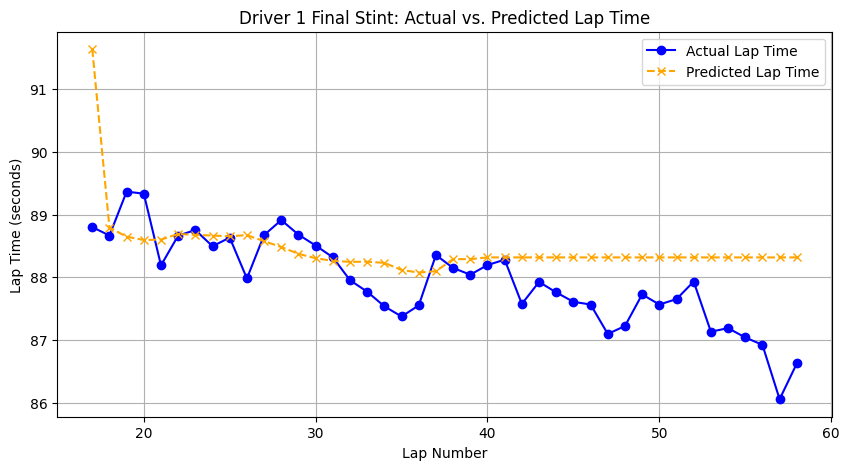

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

laps=pd.read_csv('lap_times.csv')
results=pd.read_csv('results.csv')
pits=pd.read_csv('pit_stops.csv')

target_race_id=1010

finishers=results[(results['raceId']==target_race_id)&(results['positionText'].str.isnumeric())]
target_drivers=finishers['driverId'].unique()[:8]

df=laps[(laps['raceId']==target_race_id)&(laps['driverId'].isin(target_drivers))].copy()
df=df.merge(results[['raceId','driverId','grid']],on=['raceId','driverId'],how='left')

initial_count=len(df)

pit_laps=pits[pits['raceId']==target_race_id][['driverId','lap']].copy()
pit_in_tuples=set(zip(pit_laps['driverId'],pit_laps['lap']))
pit_out_tuples=set(zip(pit_laps['driverId'],pit_laps['lap']+1))
all_pit_laps=pit_in_tuples.union(pit_out_tuples)

df['is_pit']=df.apply(lambda row:(row['driverId'],row['lap']) in all_pit_laps,axis=1)
df_clean=df[~df['is_pit']].copy()

driver_medians=df_clean.groupby('driverId')['milliseconds'].transform('median')
df_clean=df_clean[df_clean['milliseconds']<=1.5*driver_medians].copy()

removed_count=initial_count-len(df_clean)
print(f"Total laps removed: {removed_count} out of {initial_count}")

def calculate_tire_age(df):
    df=df.sort_values(by=['driverId','lap']).reset_index(drop=True)
    stints=[]
    tire_ages=[]
    for driver_id,group in df.groupby('driverId'):
        stint=1
        tire_age=0
        prev_lap=None
        for _,row in group.iterrows():
            current_lap=row['lap']
            if prev_lap is not None and current_lap>prev_lap+1:
                stint+=1
                tire_age=0
            stints.append(stint)
            tire_ages.append(tire_age)
            tire_age+=1
            prev_lap=current_lap
    df['stint']=stints
    df['tire_age']=tire_ages
    return df

df_clean=calculate_tire_age(df_clean)

max_stints=df_clean.groupby('driverId')['stint'].transform('max')
train_df=df_clean[df_clean['stint']<max_stints].copy()
test_df=df_clean[df_clean['stint']==max_stints].copy()

y_train=train_df['milliseconds']/1000.0
y_test=test_df['milliseconds']/1000.0

X_train_base=train_df[['grid','lap']]
X_test_base=test_df[['grid','lap']]
X_train_enh=train_df[['grid','lap','tire_age']]
X_test_enh=test_df[['grid','lap','tire_age']]

models={
    'Linear Regression':LinearRegression(),
    'Random Forest':RandomForestRegressor(n_estimators=100,random_state=42)
}

results_list=[]
for name,model in models.items():
    model.fit(X_train_base,y_train)
    preds_base=model.predict(X_test_base)
    rmse_base=np.sqrt(mean_squared_error(y_test,preds_base))
    mae_base=mean_absolute_error(y_test,preds_base)
    model.fit(X_train_enh,y_train)
    preds_enh=model.predict(X_test_enh)
    rmse_enh=np.sqrt(mean_squared_error(y_test,preds_enh))
    mae_enh=mean_absolute_error(y_test,preds_enh)
    results_list.append({
        'Algorithm':name,
        'Baseline RMSE':round(rmse_base,3),
        'Baseline MAE':round(mae_base,3),
        'Enhanced RMSE':round(rmse_enh,3),
        'Enhanced MAE':round(mae_enh,3)
    })

comparison_df=pd.DataFrame(results_list)
print(comparison_df.to_string(index=False))

sample_driver_id=test_df['driverId'].iloc[0]
driver_test=test_df[test_df['driverId']==sample_driver_id].copy()

rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train_enh,y_train)

driver_test['predicted_time']=rf.predict(driver_test[['grid','lap','tire_age']])
driver_test['actual_time']=driver_test['milliseconds']/1000.0

plt.figure(figsize=(10,5))
plt.plot(driver_test['lap'],driver_test['actual_time'],label='Actual Lap Time',marker='o',color='blue')
plt.plot(driver_test['lap'],driver_test['predicted_time'],label='Predicted Lap Time',linestyle='--',marker='x',color='orange')
plt.title(f'Driver {sample_driver_id} Final Stint: Actual vs. Predicted Lap Time')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.legend()
plt.grid(True)
plt.savefig('stint_visualization.png')
plt.show()